In [1]:
# Core data handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & unsupervised learning models
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Dimensionality reduction techniques for visualizing clusters
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Notebook display settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42  # for reproducibility across KMeans / t-SNE runs

# Loading the data set 

In [5]:
DATA_PATH = r'C:\Users\i.Tech Computers\Desktop\DeveloperHub_Internship\Customer Segmentation Using Unsupervised Learning\files\Mall_Customers.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset from '{DATA_PATH}' with shape {df.shape}")
except FileNotFoundError:
    # Fallback: generate a synthetic dataset that mirrors the structure/distribution
    # of the real Mall Customers dataset, purely so the notebook is runnable end-to-end
    # without the actual file present. Replace this with the real CSV for the final submission.
    print(f"'{DATA_PATH}' not found — generating a synthetic placeholder dataset instead.")
    rng = np.random.default_rng(RANDOM_STATE)
    n = 200
    df = pd.DataFrame({
        'CustomerID': np.arange(1, n + 1),
        'Gender': rng.choice(['Male', 'Female'], size=n, p=[0.44, 0.56]),
        'Age': rng.integers(18, 70, size=n),
        'Annual Income (k$)': rng.integers(15, 137, size=n),
        'Spending Score (1-100)': rng.integers(1, 100, size=n)
    })

df.head()

Loaded real dataset from 'C:\Users\i.Tech Computers\Desktop\DeveloperHub_Internship\Customer Segmentation Using Unsupervised Learning\files\Mall_Customers.csv' with shape (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Exploratory Data Analysis (EDA)

In [6]:
# General structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
# Check for missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
# Summary statistics for numerical columns
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


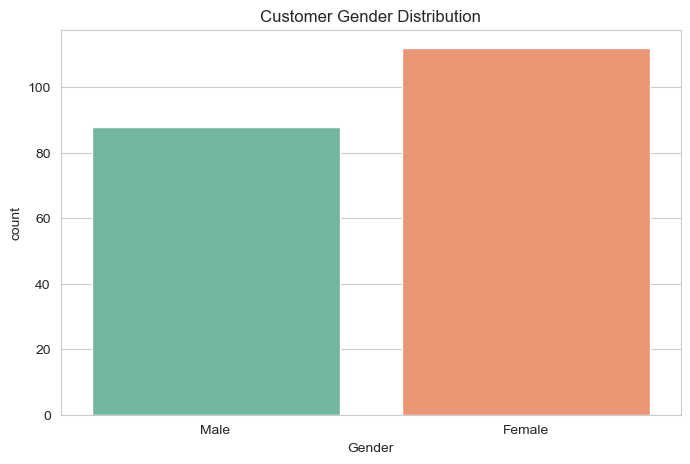

In [9]:
# Gender distribution
plt.figure()
sns.countplot(data=df, x='Gender', hue='Gender', palette='Set2', legend=False)
plt.title('Customer Gender Distribution')
plt.show()

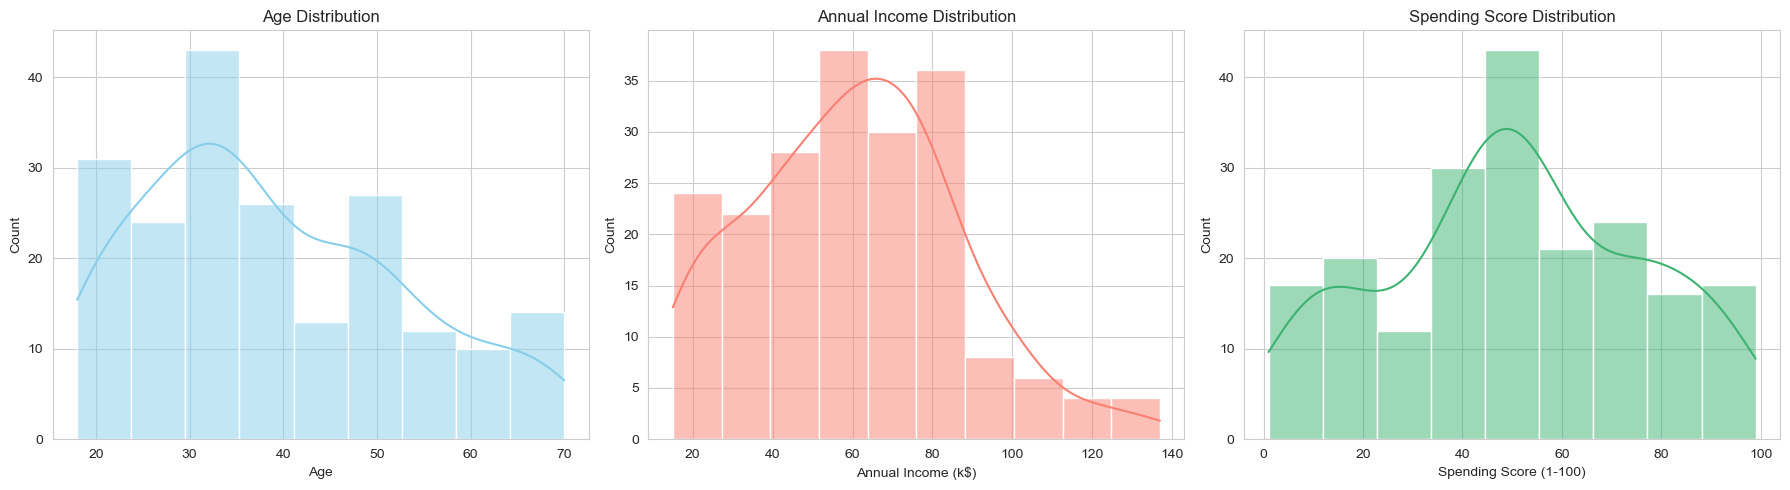

In [10]:
# Distribution of Age, Annual Income, and Spending Score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

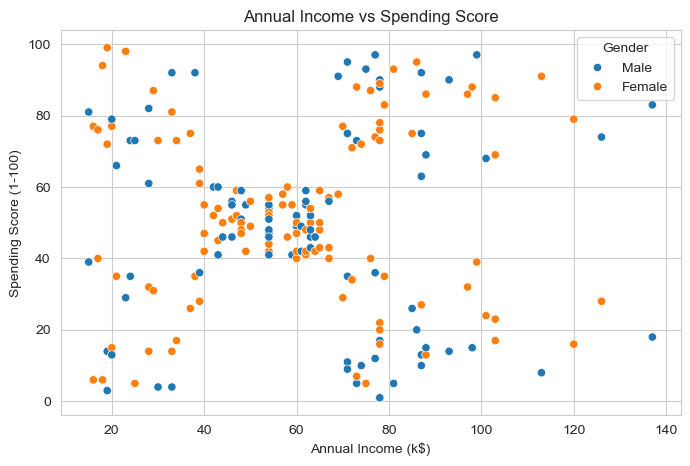

In [11]:
# Relationship between Annual Income and Spending Score (the two features we will cluster on)
plt.figure()
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.title('Annual Income vs Spending Score')
plt.show()

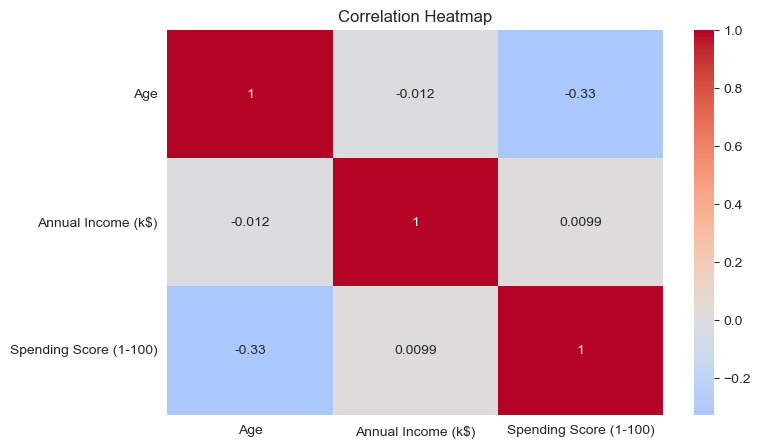

In [12]:
# Correlation heatmap among numerical features
plt.figure()
numeric_df = df.select_dtypes(include=np.number).drop(columns=['CustomerID'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Feature Selection & Scaling

In [13]:
# Features used for segmentation
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

# Standardize features so they contribute equally to the distance calculation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

# K-Mean Clustering

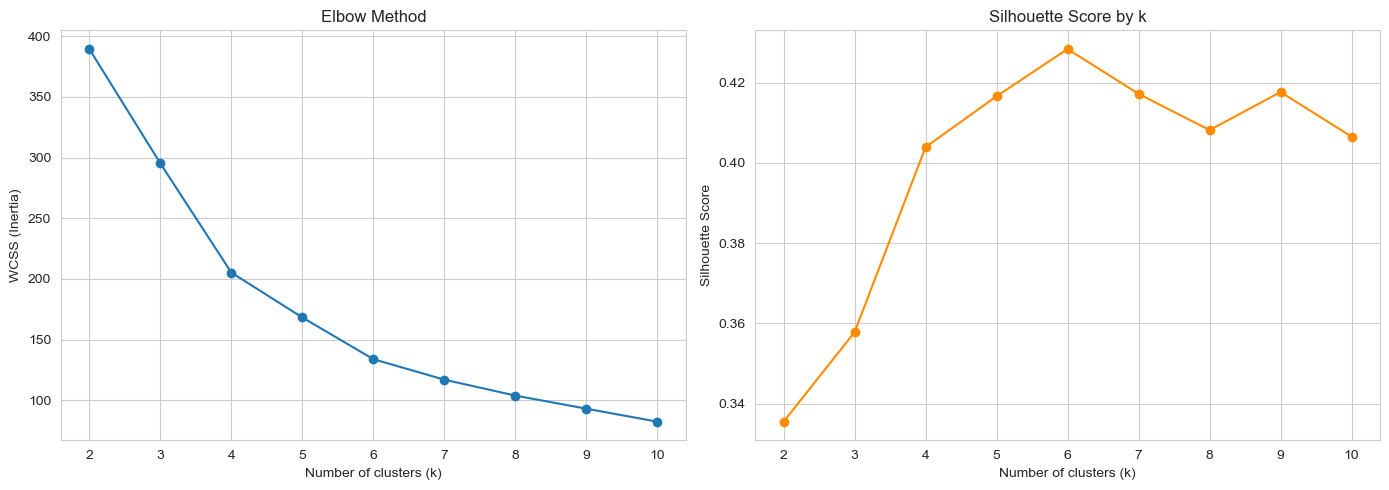

In [15]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)


wcss = []          # within-cluster sum of squares (inertia) for each k
sil_scores = []     # silhouette score for each k
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), wcss, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [16]:
OPTIMAL_K = 5  # <-- update this based on the elbow/silhouette plots above if needed

kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Final silhouette score with k={OPTIMAL_K}: {silhouette_score(X_scaled, df['Cluster']):.3f}")
df.head()

Final silhouette score with k=5: 0.417


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


# cluster profiling

In [17]:
cluster_profile = df.groupby('Cluster')[features].mean().round(1)
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,46.2,26.8,18.4,20
1,25.2,41.1,62.2,54
2,32.9,86.1,81.5,40
3,39.9,86.1,19.4,39
4,55.6,54.4,48.9,47


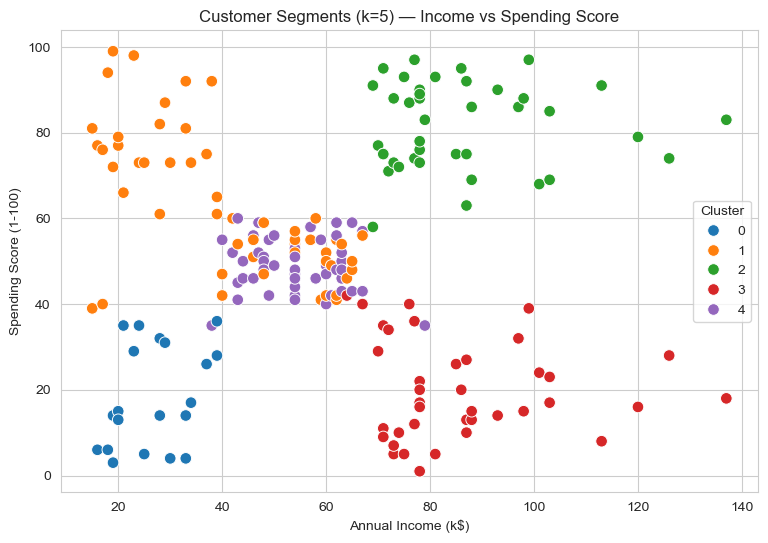

In [18]:
# Visualize clusters on the two primary business dimensions: Income vs Spending Score
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='tab10', s=70)
plt.title(f'Customer Segments (k={OPTIMAL_K}) — Income vs Spending Score')
plt.legend(title='Cluster')
plt.show()

# Dimensionality Reduction: PCA & t-SNE Visualization

Explained variance ratio (PCA): [0.443 0.333]
Total variance captured by 2 components: 77.6%


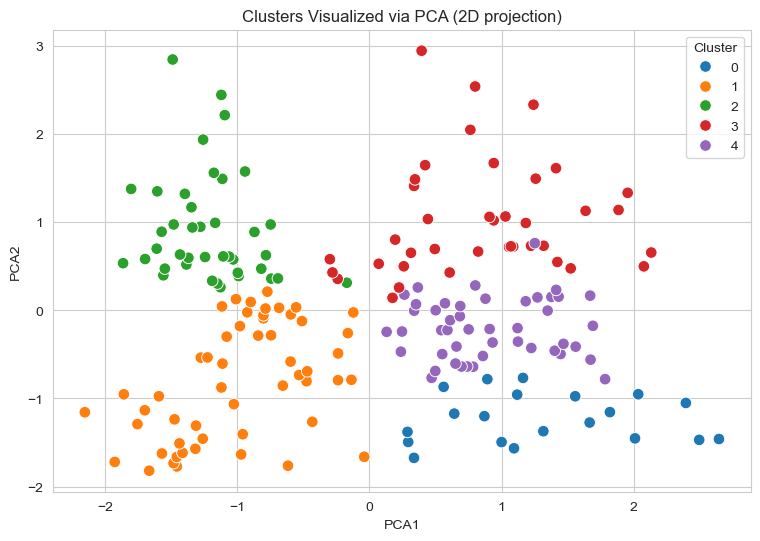

In [19]:
# --- PCA: linear projection preserving global variance ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_components = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_components[:, 0], pca_components[:, 1]

print(f"Explained variance ratio (PCA): {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=70)
plt.title('Clusters Visualized via PCA (2D projection)')
plt.show()

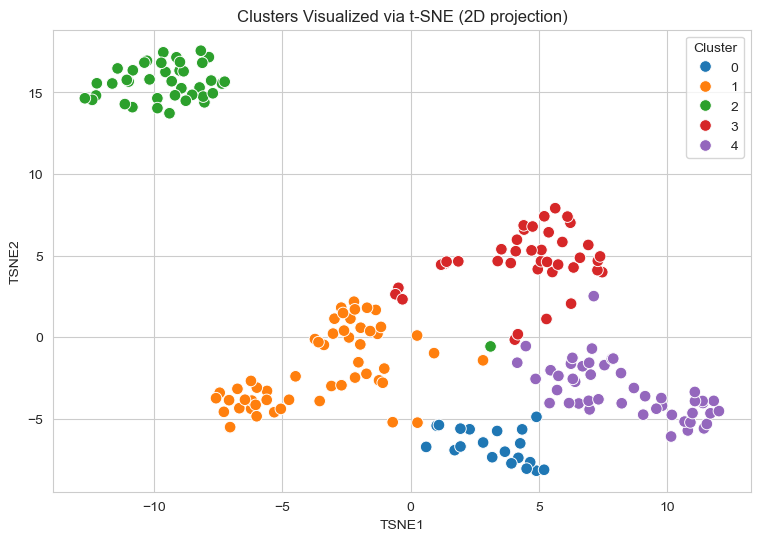

In [20]:
# --- t-SNE: non-linear projection preserving local neighborhood structure ---
# perplexity is capped relative to sample size to avoid errors on small datasets
perplexity_value = min(30, max(5, len(df) // 5))
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=perplexity_value, init='pca')
tsne_components = tsne.fit_transform(X_scaled)
df['TSNE1'], df['TSNE2'] = tsne_components[:, 0], tsne_components[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Cluster', palette='tab10', s=70)
plt.title('Clusters Visualized via t-SNE (2D projection)')
plt.show()


In [21]:
# Re-display the profile table for quick reference when mapping clusters to the segments above
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,46.2,26.8,18.4,20
1,25.2,41.1,62.2,54
2,32.9,86.1,81.5,40
3,39.9,86.1,19.4,39
4,55.6,54.4,48.9,47


# Conclusion 

- EDA showed customers vary independently across Age, Income, and Spending Score, making them suitable
  clustering features.
      
- The Elbow Method and Silhouette Score both supported choosing k = 5 clusters for K-Means.
    
- PCA and t-SNE visualizations confirmed the clusters are well-separated and meaningful, not artifacts
  of the algorithm.
      
- Each resulting segment maps to a distinct customer behavior profile, enabling targeted, ROI-focused
  marketing strategies rather than a one-size-fits-all approach.